# Lab 3 – From Raw Text to Flattened Feature Vectors
**Objective:** Understand how raw textual data is transformed into numerical representations and converted
into a flattened feature vector using tokenization and word embeddings.

**Pipeline:** Raw text → preprocessing → vocabulary → token IDs → padding → word embeddings → flattening → PCA visualization

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 120)

## Task 1 – Text Pre-processing and Vocabulary

In [2]:
reviews = [
    "The product quality is excellent",
    "I really love this product",
    "The quality of this item is amazing",
    "The product performance is poor",
    "I dislike this product completely",
]

def preprocess(text):
    text = text.lower()                                                # 1. lowercase
    text = text.translate(str.maketrans("", "", string.punctuation))  # 2. remove punctuation
    return re.split(r"\s+", text.strip())                             # 3. whitespace tokenization

tokenized = [preprocess(r) for r in reviews]
for i, (r, t) in enumerate(zip(reviews, tokenized), 1):
    print(f"{i}. {r!r:42} -> {t}")

1. 'The product quality is excellent'         -> ['the', 'product', 'quality', 'is', 'excellent']
2. 'I really love this product'               -> ['i', 'really', 'love', 'this', 'product']
3. 'The quality of this item is amazing'      -> ['the', 'quality', 'of', 'this', 'item', 'is', 'amazing']
4. 'The product performance is poor'          -> ['the', 'product', 'performance', 'is', 'poor']
5. 'I dislike this product completely'        -> ['i', 'dislike', 'this', 'product', 'completely']


In [3]:
# Unique words in order of first appearance (deterministic)
vocabulary = list(dict.fromkeys(w for sent in tokenized for w in sent))
print(f"Vocabulary ({len(vocabulary)} unique words):")
print(vocabulary)

Vocabulary (16 unique words):
['the', 'product', 'quality', 'is', 'excellent', 'i', 'really', 'love', 'this', 'of', 'item', 'amazing', 'performance', 'poor', 'dislike', 'completely']


## Task 2 – Token IDs
Special tokens:
* `<PAD>` = **0** – used to fill shorter sequences (ID 0 is the Keras convention for padding / masking).
* `<UNK>` = **1** – reserved for words not seen in the vocabulary (useful for new reviews at inference time).

Real words get IDs from 2 onward, in order of first appearance, so the mapping is fixed and reproducible:
the same word always maps to the same ID.

In [4]:
PAD, UNK = "<PAD>", "<UNK>"
word2id = {PAD: 0, UNK: 1}
for w in vocabulary:
    word2id.setdefault(w, len(word2id))
id2word = {i: w for w, i in word2id.items()}
VOCAB_SIZE = len(word2id)

vocab_table = pd.DataFrame({"Word": list(word2id.keys()), "Token ID": list(word2id.values())})
print(f"Total vocabulary size (incl. special tokens): {VOCAB_SIZE}\n")
print(vocab_table.to_string(index=False))

Total vocabulary size (incl. special tokens): 18

       Word  Token ID
      <PAD>         0
      <UNK>         1
        the         2
    product         3
    quality         4
         is         5
  excellent         6
          i         7
     really         8
       love         9
       this        10
         of        11
       item        12
    amazing        13
performance        14
       poor        15
    dislike        16
 completely        17


## Task 3 – Token Sequence Representation

In [5]:
def encode(tokens):
    return [word2id.get(w, word2id[UNK]) for w in tokens]

sequences = [encode(t) for t in tokenized]
for r, s in zip(reviews, sequences):
    print(f'Sentence:\n"{r}"\nToken sequence:\n{s}\n')

# consistency check: identical words share IDs across sentences (e.g. 'product', 'the', 'is', 'this')
for w in ["the", "product", "is", "this"]:
    print(f"'{w}' -> {word2id[w]} in every sentence it appears in")

Sentence:
"The product quality is excellent"
Token sequence:
[2, 3, 4, 5, 6]

Sentence:
"I really love this product"
Token sequence:
[7, 8, 9, 10, 3]

Sentence:
"The quality of this item is amazing"
Token sequence:
[2, 4, 11, 10, 12, 5, 13]

Sentence:
"The product performance is poor"
Token sequence:
[2, 3, 14, 5, 15]

Sentence:
"I dislike this product completely"
Token sequence:
[7, 16, 10, 3, 17]

'the' -> 2 in every sentence it appears in
'product' -> 3 in every sentence it appears in
'is' -> 5 in every sentence it appears in
'this' -> 10 in every sentence it appears in


## Task 4 – Padding

In [6]:
lengths = [len(s) for s in sequences]
MAX_LEN = max(lengths)
print("Sequence lengths:", lengths)
print("Maximum sequence length:", MAX_LEN)

# Post-padding with <PAD> (ID 0)
padded = np.array([s + [word2id[PAD]] * (MAX_LEN - len(s)) for s in sequences])

cols = [f"t{i+1}" for i in range(MAX_LEN)]
pad_df = pd.DataFrame(padded, columns=cols, index=[f"Review {i+1}" for i in range(len(reviews))])
print("\nPadded token ID matrix, shape", padded.shape)
display(pad_df)

print("Same matrix decoded back to words:")
display(pad_df.apply(lambda col: col.map(id2word)))

Sequence lengths: [5, 5, 7, 5, 5]
Maximum sequence length: 7

Padded token ID matrix, shape (5, 7)


,t1,t2,t3,t4,t5,t6,t7
Review 1,2,3,4,5,6,0,0
Review 2,7,8,9,10,3,0,0
Review 3,2,4,11,10,12,5,13
Review 4,2,3,14,5,15,0,0
Review 5,7,16,10,3,17,0,0


Same matrix decoded back to words:


,t1,t2,t3,t4,t5,t6,t7
Review 1,the,product,quality,is,excellent,<PAD>,<PAD>
Review 2,i,really,love,this,product,<PAD>,<PAD>
Review 3,the,quality,of,this,item,is,amazing
Review 4,the,product,performance,is,poor,<PAD>,<PAD>
Review 5,i,dislike,this,product,completely,<PAD>,<PAD>


**Why padding is required:** neural network layers operate on fixed-shape tensors, and a batch of sentences
must form a rectangular matrix `(num_sentences, max_len)`. Reviews naturally have different lengths
(5, 5, 7, 5, 5 words here), so shorter sequences are filled with the `<PAD>` token (ID 0) until every
sequence has length `MAX_LEN = 7`. Because `<PAD>` has a reserved ID, the model (e.g. with `mask_zero=True`)
can learn to ignore these positions.

## Task 5 – Word Embeddings
A Keras `Embedding` layer is a trainable lookup table of shape `(vocab_size, embedding_dim)`.
Each token ID selects one row → a dense vector. Here the weights are freshly (randomly) initialized
with a fixed seed so the result is reproducible; in a real model they would be learned during training.
If TensorFlow is not installed, an equivalent seeded NumPy lookup table is used.

In [7]:
EMBEDDING_DIM = 8

try:
    import tensorflow as tf
    tf.keras.utils.set_random_seed(SEED)
    embedding_layer = tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, name="word_embedding")
    embedded = embedding_layer(tf.constant(padded)).numpy()
    embedding_matrix = embedding_layer.get_weights()[0]
    backend = f"TensorFlow {tf.__version__} / Keras Embedding layer"
except ImportError:
    rng = np.random.default_rng(SEED)
    # same default init as Keras: uniform(-0.05, 0.05)
    embedding_matrix = rng.uniform(-0.05, 0.05, size=(VOCAB_SIZE, EMBEDDING_DIM)).astype("float32")
    embedded = embedding_matrix[padded]
    backend = "NumPy lookup table (TensorFlow not available)"

print("Embedding backend    :", backend)
print("Vocabulary size      :", VOCAB_SIZE)
print("Embedding dimension  :", EMBEDDING_DIM)
print("Embedding matrix     :", embedding_matrix.shape, "-> (vocab_size, embedding_dim)")
print("Padded input         :", padded.shape, "-> (num_sentences, max_len)")
print("Embedded output      :", embedded.shape, "-> (num_sentences, max_len, embedding_dim)")

Embedding backend    : NumPy lookup table (TensorFlow not available)
Vocabulary size      : 18
Embedding dimension  : 8
Embedding matrix     : (18, 8) -> (vocab_size, embedding_dim)
Padded input         : (5, 7) -> (num_sentences, max_len)
Embedded output      : (5, 7, 8) -> (num_sentences, max_len, embedding_dim)


In [8]:
emb_df = pd.DataFrame(embedding_matrix, index=[f"{id2word[i]} ({i})" for i in range(VOCAB_SIZE)],
                      columns=[f"d{j+1}" for j in range(EMBEDDING_DIM)]).round(4)
print("Embedding matrix (one dense vector per token):")
display(emb_df)

Embedding matrix (one dense vector per token):


,d1,d2,d3,d4,d5,d6,d7,d8
<PAD> (0),0.0274,-0.0061,0.0359,0.0197,-0.0406,0.0476,0.0261,0.0286
<UNK> (1),-0.0372,-0.0050,-0.0129,0.0427,0.0144,0.0323,-0.0057,-0.0273
the (2),0.0055,-0.0436,0.0328,0.0132,0.0258,-0.0145,0.0471,0.0393
product (3),0.0278,-0.0305,-0.0033,-0.0456,-0.0346,0.0183,0.0245,0.0468
quality (4),-0.0174,-0.0130,-0.0030,-0.0311,-0.0370,-0.0024,-0.0273,0.0170
is (5),-0.0063,0.0333,0.0200,-0.0188,0.0332,0.0305,-0.0113,-0.0212
excellent (6),0.0182,-0.0360,-0.0300,-0.0493,0.0287,0.0165,0.0205,0.0281
i (7),-0.0041,0.0069,-0.0360,-0.0385,0.0168,-0.0029,0.0065,0.0265
really (8),0.0135,0.0054,0.0059,-0.0196,-0.0469,-0.0063,-0.0285,-0.0091
love (9),0.0353,-0.0266,-0.0442,-0.0219,-0.0206,0.0162,0.0057,0.0284


In [9]:
print(f'Embedding of Review 1: "{reviews[0]}"  shape = {embedded[0].shape}')
display(pd.DataFrame(embedded[0], index=[id2word[i] for i in padded[0]],
                     columns=[f"d{j+1}" for j in range(EMBEDDING_DIM)]).round(4))

# sanity check: the same word gets the same vector everywhere
same = np.allclose(embedded[0, 1], embedded[3, 1])  # 'product' in review 1 and review 4
print("Vector for 'product' identical in Review 1 and Review 4:", same)

Embedding of Review 1: "The product quality is excellent"  shape = (7, 8)


,d1,d2,d3,d4,d5,d6,d7,d8
the,0.0055,-0.0436,0.0328,0.0132,0.0258,-0.0145,0.0471,0.0393
product,0.0278,-0.0305,-0.0033,-0.0456,-0.0346,0.0183,0.0245,0.0468
quality,-0.0174,-0.0130,-0.0030,-0.0311,-0.0370,-0.0024,-0.0273,0.0170
is,-0.0063,0.0333,0.0200,-0.0188,0.0332,0.0305,-0.0113,-0.0212
excellent,0.0182,-0.0360,-0.0300,-0.0493,0.0287,0.0165,0.0205,0.0281
<PAD>,0.0274,-0.0061,0.0359,0.0197,-0.0406,0.0476,0.0261,0.0286
<PAD>,0.0274,-0.0061,0.0359,0.0197,-0.0406,0.0476,0.0261,0.0286


Vector for 'product' identical in Review 1 and Review 4: True


**Shape explanation:** `(5, 7, 8)` = **5** sentences × **7** tokens per (padded) sentence × **8** numbers per token.

## Task 6 – Flattening
Flattening concatenates the 7 token vectors of each sentence into a single feature vector of length
`MAX_LEN × EMBEDDING_DIM = 7 × 8 = 56`, which can be fed to a classical classifier or a Dense layer.

In [10]:
flattened = embedded.reshape(embedded.shape[0], -1)   # equivalent to keras.layers.Flatten()
print("Before flattening:", embedded.shape, "-> (num_sentences, max_len, embedding_dim)")
print("After  flattening:", flattened.shape, f"-> (num_sentences, max_len * embedding_dim = {MAX_LEN}*{EMBEDDING_DIM})")

flat_df = pd.DataFrame(flattened, index=[f"Review {i+1}" for i in range(len(reviews))],
                       columns=[f"f{j+1}" for j in range(flattened.shape[1])]).round(3)
display(flat_df.iloc[:, :16])
print("(first 16 of 56 features shown)")

# the first 8 features of each flattened vector are exactly the first token's embedding
print("flattened[0][:8] == embedding of first token 'the':", np.allclose(flattened[0, :8], embedded[0, 0]))

Before flattening: (5, 7, 8) -> (num_sentences, max_len, embedding_dim)
After  flattening: (5, 56) -> (num_sentences, max_len * embedding_dim = 7*8)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16
Review 1,0.005,-0.044,0.033,0.013,0.026,-0.015,0.047,0.039,0.028,-0.031,-0.003,-0.046,-0.035,0.018,0.024,0.047
Review 2,-0.004,0.007,-0.036,-0.039,0.017,-0.003,0.007,0.026,0.013,0.005,0.006,-0.020,-0.047,-0.006,-0.029,-0.009
Review 3,0.005,-0.044,0.033,0.013,0.026,-0.015,0.047,0.039,-0.017,-0.013,-0.003,-0.031,-0.037,-0.002,-0.027,0.017
Review 4,0.005,-0.044,0.033,0.013,0.026,-0.015,0.047,0.039,0.028,-0.031,-0.003,-0.046,-0.035,0.018,0.024,0.047
Review 5,-0.004,0.007,-0.036,-0.039,0.017,-0.003,0.007,0.026,-0.040,0.009,-0.033,0.043,0.008,-0.015,0.009,-0.048


(first 16 of 56 features shown)
flattened[0][:8] == embedding of first token 'the': True


## Task 7 – PCA Visualization
PCA projects the high-dimensional vectors down to 2 components so we can plot them:
* **(a)** each 56-dim flattened sentence vector → 2D
* **(b)** each 8-dim word embedding → 2D

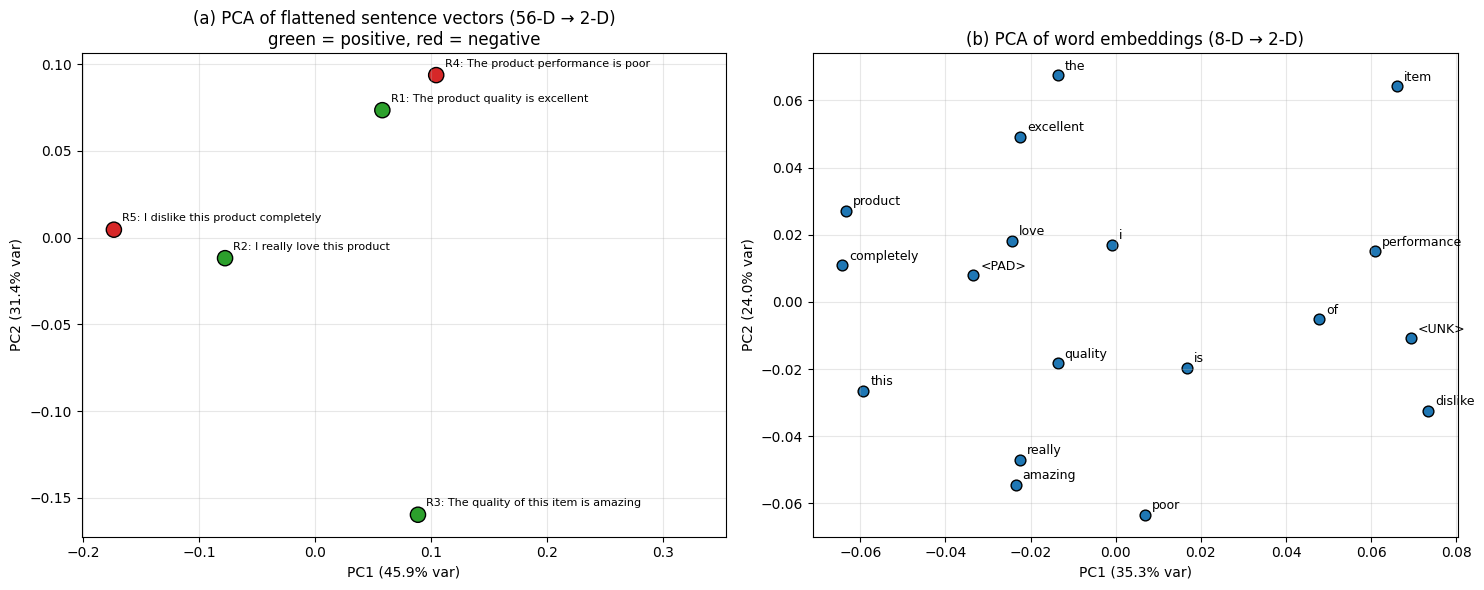

Sentence PCA 2-D coordinates:


,PC1,PC2
Review 1,0.0580,0.0734
Review 2,-0.0776,-0.0119
Review 3,0.0887,-0.1598
Review 4,0.1044,0.0936
Review 5,-0.1735,0.0045


In [11]:
pca_sent = PCA(n_components=2, random_state=SEED)
sent_2d = pca_sent.fit_transform(flattened)

pca_word = PCA(n_components=2, random_state=SEED)
word_2d = pca_word.fit_transform(embedding_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
colors = ["tab:green", "tab:green", "tab:green", "tab:red", "tab:red"]
ax.scatter(sent_2d[:, 0], sent_2d[:, 1], c=colors, s=120, edgecolor="k")
for i, (x, y) in enumerate(sent_2d):
    ax.annotate(f"R{i+1}: {reviews[i]}", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)
xr = np.ptp(sent_2d[:, 0])
ax.set_xlim(sent_2d[:, 0].min() - 0.1 * xr, sent_2d[:, 0].max() + 0.9 * xr)  # room for labels
ax.set_title("(a) PCA of flattened sentence vectors (56-D → 2-D)\ngreen = positive, red = negative")
ax.set_xlabel(f"PC1 ({pca_sent.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_sent.explained_variance_ratio_[1]:.1%} var)")
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(word_2d[:, 0], word_2d[:, 1], s=60, c="tab:blue", edgecolor="k")
for i, (x, y) in enumerate(word_2d):
    ax.annotate(id2word[i], (x, y), textcoords="offset points", xytext=(5, 4), fontsize=9)
ax.set_title("(b) PCA of word embeddings (8-D → 2-D)")
ax.set_xlabel(f"PC1 ({pca_word.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_word.explained_variance_ratio_[1]:.1%} var)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()

print("Sentence PCA 2-D coordinates:")
display(pd.DataFrame(sent_2d, columns=["PC1", "PC2"], index=[f"Review {i+1}" for i in range(5)]).round(4))

**Interpretation:** the embedding layer is untrained, so its vectors are random and the PCA plots do **not**
yet separate positive from negative reviews or group similar words (e.g. *excellent*/*amazing*). The sentence
points mostly reflect shared words and padding: reviews 1 and 4 (*"The product … is …"*) share 3 of 5 token
positions and tend to lie closer together. After training the embedding on a task such as sentiment
classification, words with similar meaning would move closer and positive/negative reviews would form
separate clusters.

## Summary of Shapes

| Stage | Representation | Shape |
|---|---|---|
| Raw text | list of 5 strings | 5 |
| Token IDs | variable-length lists | lengths 5, 5, 7, 5, 5 |
| Padded | integer matrix | (5, 7) |
| Embedding matrix | lookup table | (18, 8) |
| Embedded | dense 3-D tensor | (5, 7, 8) |
| Flattened | feature vectors | (5, 56) |
| PCA | 2-D projection | (5, 2) |

## Conclusion
Text was lower-cased, cleaned and tokenized; a 16-word vocabulary (+ `<PAD>`, `<UNK>`) mapped each word to a
fixed integer ID. Sequences were padded to a common length of 7, looked up in an 8-dimensional embedding layer to
produce a `(5, 7, 8)` tensor, and flattened into `(5, 56)` feature vectors, which PCA reduced to 2-D for
visualization. This is exactly the input pipeline used before the Dense/Flatten layers of a text classifier.